In [2]:
import os
import json

import time
import random
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split
import torchvision.transforms as T
import torch.nn.functional as F
import pickle
import gzip


In [3]:
from google.colab import drive
drive.mount('/content/drive')
base_dir = '/content/drive/My Drive/Colab Notebooks/'
# base_dir = ''

Mounted at /content/drive


In [4]:
# 1. Original IPN Hand dataset (videos)
ipn_path = kagglehub.dataset_download("soumicksarker/ipn-hand-dataset")
print("IPN dataset:", ipn_path)

# --- Paths ---
videos_dir = os.path.join(ipn_path, "videos/videos")  # raw video files

annotations_path = os.path.join(ipn_path, "annotations/annotations")

def read_annotations(path):
    with open(path, 'r') as f:
        annots = []
        for idx, line in enumerate(f):
            if idx > 0:
                # Parse annotations and convert frame info into ints
                info = line.split(',')
                for i in range(2, len(info)):
                    info[i] = int(info[i])
                annots.append(info)
    return annots

annots = read_annotations(os.path.join(annotations_path, "Annot_List.txt"))


100%|██████████| 4.61G/4.61G [00:59<00:00, 83.0MB/s]

Extracting files...


IPN dataset: /root/.cache/kagglehub/datasets/soumicksarker/ipn-hand-dataset/versions/7


In [5]:
# Use the same UNet() model from UNetScratchModel to extract segmentations

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # Encoder
        for f in features:
            self.downs.append(self.conv_block(in_channels, f))
            in_channels = f

        # Bottleneck
        self.bottleneck = self.conv_block(features[-1], features[-1]*2)

        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, kernel_size=2, stride=2))
            self.ups.append(self.conv_block(f*2, f))

        # Final output
        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, 2)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx+1](x)

        return torch.sigmoid(self.final(x))

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )


In [6]:
class IPNDataPreProcessor:
    def __init__(self, annots, vid_path, transform = None):
        self.videos_path = vid_path

        self.annots = annots
        self.n = len(annots)
        self.videos_path = vid_path
        self.annots = annots
        self.transform = transform

        # Constants
        self.min_frames = 5
        self.num_frames = 80

        self.TARGET_SIZE = (256, 256)


    def __len__(self):
        return len(self.annots)

    def get_frames(self, video_name, start_frame, end_frame):
        video_path = os.path.join(self.videos_path, video_name + ".avi")

        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        if not cap.isOpened():
            raise FileNotFoundError(f"Video file not found: {video_path}")

        frames = []

        for frame_i in range(start_frame, end_frame):

            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, self.TARGET_SIZE)
            frames.append(frame)

        cap.release()

        return frames

    def __getitem__(self, idx):
        info = self.annots[idx]
        video_name, label, label_id, start_frame, end_frame, num_frames = info
        frames = self.get_frames(video_name, start_frame, end_frame)

        # # Pad/truncate to fixed length
        frames = self.pad_sequence(frames, self.num_frames)

        # Convert to tensors
        frames = torch.tensor(np.stack(frames)).permute(0,3,1,2).float() / 255.0

        return frames, label_id

    def pad_sequence(self, seq, target_len):
        seq_len = len(seq)
        if seq_len >= target_len:
            return seq[:target_len]

        pad_item = np.zeros_like(seq[0])
        padding = [pad_item.copy() for _ in range(target_len - seq_len)]
        return seq + padding


In [7]:
# Extract all segmentation masks

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

save_path = os.path.join(base_dir, "models", "hand_seg_model.pth")
save_path_seg = os.path.join(base_dir, "videos", "segmented_vids_500_compressed.pkl.gz")
out_path = os.path.join(base_dir, "videos")
device = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(save_path):
    raise FileNotFoundError(
        f"❌ The file {save_path} does NOT exist.\n"
        f"Set TRAIN_NEW_MODEL = True to train a new model first."
    )


transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])


dataset = IPNDataPreProcessor(
    annots,
    vid_path=videos_dir,
    transform=transform
)


ID_TO_GESTURE = {
    0: "Non-gesture",
    1: "Pointing with one finger",
    2: "Pointing with two fingers",
    3: "Click with one finger",
    4: "Click with two fingers",
    5: "Throw up",
    6: "Throw down",
    7: "Throw left",
    8: "Throw right",
    9: "Open twice",
    10: "Double click with one finger",
    11: "Double click with two fingers",
    12: "Zoom in",
    13: "Zoom out",
}


all_masks = []
all_labels = []

if False: # set to false to not recalculate
    # Make a dataset from the processed frames
    print(len(dataset))

    unet_model = UNet().to(device)
    unet_model.load_state_dict(torch.load(save_path, map_location=device))
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    unet_model.eval()
    for seq_idx, (imgs, labels) in enumerate(loader):
        # just get first 500 vids processed
        if seq_idx > 500:
            break

        # imgs: [1, T, C, H, W] or similar
        imgs = imgs.squeeze(0)  # remove batch dim
        num_frames = imgs.shape[0]

        # Prepare video writer
        video_name = f"segmented_{seq_idx}.mp4"
        height, width = imgs.shape[2], imgs.shape[3]  # H, W
        fps = 30

        frames = []
        for i in range(num_frames):
            frame = imgs[i].unsqueeze(0).to(device)  # add batch dim
            with torch.no_grad():
                pred = unet_model(frame)
                print(i, end='\r')

            # Convert to numpy and scale to 0-255
            mask_np = (pred.squeeze().cpu().numpy() * 255).astype('uint8')

            # Resize mask to original frame size
            mask_resized = cv2.resize(mask_np, (width, height))
            mask_tensor = torch.from_numpy(mask_resized).unsqueeze(0)


            frames.append(mask_tensor)

        all_masks.append(torch.stack(frames))
        all_labels.append(labels)

        print(f"Saved segmented video: {seq_idx}")

    # torch.save({
    #     "masks": all_masks,
    #     "labels": all_labels
    # }, save_path_seg, pickle_protocol=4)

    data = {
        "masks": all_masks,
        "labels": all_labels
    }

    with gzip.open(save_path_seg, 'wb') as f:
        pickle.dump(data, f, protocol=5)
else:
    if not os.path.exists(save_path_seg):
        raise FileNotFoundError(
            f"❌ The file {save_path_seg} does NOT exist.\n"
            f"Set TRAIN_NEW_MODEL = True to train a new model first."
        )
    else:
        with gzip.open(save_path_seg, 'rb') as f:
            data = pickle.load(f)
        # data = torch.load(save_path_seg)
        all_masks = data["masks"]
        all_labels = data["labels"]


In [8]:
class SegmentedSequenceDataset(Dataset):
    def __init__(self, pt_file):
        # data = torch.load(pt_file)
        with gzip.open(save_path_seg, 'rb') as f:
            data = pickle.load(f)
        self.masks = data["masks"]     # list of tensors [T, H, W]
        self.labels = data["labels"]   # list of tensors [T]

    def __len__(self):
        return len(self.masks)  # number of sequences

    def __getitem__(self, idx):
        return self.masks[idx], self.labels[idx]  # ([T,H,W], [T])

In [9]:
dataset = SegmentedSequenceDataset(save_path_seg)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

dataset_size = len(dataset)

# Optionally, fix random seed for reproducibility
torch.manual_seed(42)

val_fraction = 0.2  # 20% of data for validation
val_size = int(dataset_size * val_fraction)
train_size = dataset_size - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [10]:
frames, label = dataset[0]
print(frames.shape, label.shape)

class CNNEncoder(nn.Module):
    """
    Simple CNN to encode a frame into a feature vector
    """
    def __init__(self, input_channels=1, feature_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),  # [B,32,H,W]
            nn.ReLU(),
            nn.MaxPool2d(2),                               # [B,32,H/2,W/2]
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # [B,64,H/4,W/4]
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)                        # [B,128,1,1]
        )
        self.feature_dim = feature_dim

    def forward(self, x):
        x = self.conv(x)          # [B,128,1,1]
        x = x.view(x.size(0), -1) # flatten to [B,128]
        return x

class SequenceClassifier(nn.Module):
    def __init__(self, input_channels=1, cnn_feature_dim=128, hidden_dim=128, num_classes=14, rnn_layers=1):
        super().__init__()
        self.encoder = CNNEncoder(input_channels, cnn_feature_dim)
        self.rnn = nn.GRU(input_size=cnn_feature_dim, hidden_size=hidden_dim, num_layers=rnn_layers, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)           # Flatten batch+time for CNN
        features = self.encoder(x)          # [B*T, cnn_feature_dim]
        features = features.view(B, T, -1) # [B, T, cnn_feature_dim]

        rnn_out, _ = self.rnn(features)    # [B, T, hidden_dim]
        seq_feat = rnn_out[:, -1, :]       # Use last RNN output for sequence-level prediction
        logits = self.classifier(seq_feat) # [B, num_classes]
        return logits


torch.Size([80, 1, 256, 256]) torch.Size([1])


In [14]:


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for masks, labels in loader:
            labels = labels.long() - 1
            labels = labels.to(device)

            # print(labels)

            labels = labels.view(-1)  # ensures [batch_size]
            masks = masks.to(device)
            masks = masks.float()

            # Forward pass
            logits = model(masks)      # [1, num_classes]
            preds = logits.argmax(dim=1)  # [1]

            # Compare
            correct += (preds == labels).sum().item()
            total += 1

    return correct / total



In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SequenceClassifier(input_channels=1, num_classes=14).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()  # labels are integers 0..13


train_acc_list = []
test_acc_list = []

num_epochs = 30

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0
    model.train()
    for masks, labels in train_loader:
        labels = labels.long() - 1
        labels = labels.to(device)

        labels = labels.view(-1)  # ensures [batch_size]
        masks = masks.to(device)
        masks = masks.float()

        optimizer.zero_grad()
        logits = model(masks)                  # [1, num_classes]
        preds = logits.argmax(dim=1)  # [1]
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total += 1
        correct += (preds == labels).sum().item()
    train_acc = correct / total
    train_acc_list.append(train_acc)

    test_acc = evaluate_accuracy(model, val_loader, device)
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")


Epoch 1, Loss: 2.2306, Train Accuracy: 0.286783042394015, Test Accuracy: 0.28
Epoch 2, Loss: 2.0569, Train Accuracy: 0.2967581047381546, Test Accuracy: 0.25
Epoch 3, Loss: 1.9641, Train Accuracy: 0.2942643391521197, Test Accuracy: 0.28
Epoch 4, Loss: 1.9258, Train Accuracy: 0.30673316708229426, Test Accuracy: 0.27
Epoch 5, Loss: 1.8820, Train Accuracy: 0.3117206982543641, Test Accuracy: 0.27
Epoch 6, Loss: 1.8535, Train Accuracy: 0.32418952618453867, Test Accuracy: 0.3
Epoch 7, Loss: 1.8068, Train Accuracy: 0.3541147132169576, Test Accuracy: 0.29
Epoch 8, Loss: 1.7897, Train Accuracy: 0.30174563591022446, Test Accuracy: 0.3
Epoch 9, Loss: 1.7597, Train Accuracy: 0.3167082294264339, Test Accuracy: 0.31
Epoch 10, Loss: 1.6623, Train Accuracy: 0.3740648379052369, Test Accuracy: 0.29
Epoch 11, Loss: 1.6691, Train Accuracy: 0.33665835411471323, Test Accuracy: 0.33
Epoch 12, Loss: 1.6266, Train Accuracy: 0.3865336658354115, Test Accuracy: 0.32
Epoch 13, Loss: 1.5969, Train Accuracy: 0.361596

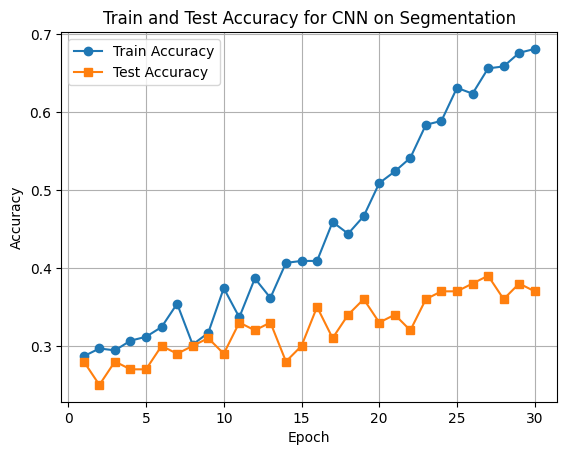

In [17]:
epochs = range(1, num_epochs+1)
plt.plot(epochs, train_acc_list, 'o-', label='Train Accuracy')
plt.plot(epochs, test_acc_list, 's-', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy for CNN on Segmentation')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# save model
model_path = os.path.join(base_dir, "models", "hand_seg_label_model.pth")

torch.save(model.state_dict(), model_path)